# Machine Learning and Analytics

## Final Project

### Marianna Kanellaki - S-001081

### Part 3: Regression

Setup

In [269]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [270]:
from regularised_polynomial_regression import ridge_train, model_matrix, test_coefficients
from BasicTree import TNode, Construct_Subtree, Predict
from polynomial_regression import train as poly_train
from polynomial_regression_CV import linear_cv
import regkernel as rkrnl
import kernel as krnl

from utils import *

In [271]:
df = pd.read_json('../data/s-001081_complete.json')
df

,age,leaf_size,berry_colour,berry_size,leaf_shape,petal_colour,petal_size,height,edible,soil_quality,species
0,7.827582,24.510278,grey,7.959125,lanceolate,white,3.118933,239.007710,False,4.101307,berrius elephas
1,7.946372,27.694587,blue,8.569603,lanceolate,white,1.259286,165.247307,True,3.105685,berrius actius
2,3.572540,45.625918,blue,11.523105,lanceolate,white,2.319500,224.763124,True,5.540744,berrius actius
3,2.290430,11.864775,green,6.010535,ovate,pink,3.159112,69.530241,False,3.790448,berrius boethiae
4,1.907052,18.736034,green,6.506491,lanceolate,white,2.477067,45.883920,False,3.215510,berrius elephas
...,...,...,...,...,...,...,...,...,...,...,...
495,6.111563,14.665505,purple,6.076126,ovate,pink,3.130601,205.911846,True,4.052288,berrius boethiae
496,1.297815,25.466863,green,7.526041,lanceolate,white,1.101837,33.783400,False,3.130843,berrius actius
497,7.127454,26.944936,purple,9.737714,ovate,white,2.584270,230.943919,False,4.123064,berrius codiae
498,1.185752,26.458160,green,9.546730,lanceolate,white,1.402115,37.092050,False,3.581669,berrius actius


In [272]:
df_encoded = pd.get_dummies(df, columns=['berry_colour', 'leaf_shape', 'petal_colour', 'species'])

X = df_encoded.drop(columns=['berry_size'])
y = df_encoded['berry_size']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_f = X_train.values.astype(float)
y_train_f = y_train.values.astype(float).reshape(-1, 1)
X_test_f = X_test.values.astype(float)
y_test_f = y_test.values.astype(float).reshape(-1, 1)

results = {}
X_train_mat = {}
X_test_mat = {}

N_SUBSET = 40

#### 3.1 Regression using different methods

##### 3.1.1 Regularized Polynomial Regression

Ridge Regression MSE Results:
  - Ridge_1: 2.6713
  - Ridge_3: 1.2158
  - Ridge_15: 11.6166


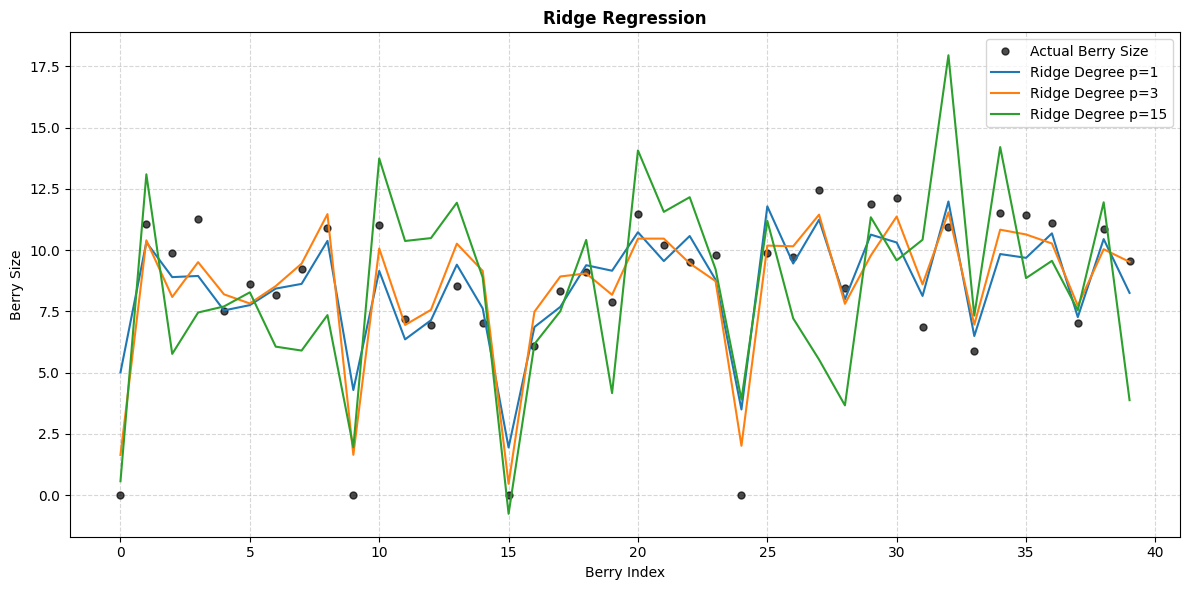

In [273]:
gamma = 0.1
ps = [1, 3, 15] # trying 3 different polynomial orders
betas_ridge = {}

for p in ps:
    X_train_mat[p] = model_matrix(p, X_train_f)
    X_test_mat[p] = model_matrix(p, X_test_f)
    
    betas_ridge[p] = ridge_train(X_train_mat[p], 
                             y_train_f, 
                             len(X_train)*gamma, 
                             X_train_mat[p].shape[1] - 1)
    
    results[f'Ridge_{p}'] = test_coefficients(len(y_test), betas_ridge[p], X_test_mat[p], y_test_f)

print_list_MSE("Ridge Regression", results, "Ridge")
plot_regression_results_multi_p("Ridge", N_SUBSET, y_test_f, ps, X_test_mat, betas_ridge)

For the Regularized Ridge Regression, I tried 3 experiments with 3 different polynomial models. The orders p=1 and p=3 both performed very well, with p=3 achieving the best results. Order p=15 shows overfitting.

##### 3.1.2 Standard Polynomial Regression

Polynomial MSE Results p=1: 0.9718471763717547


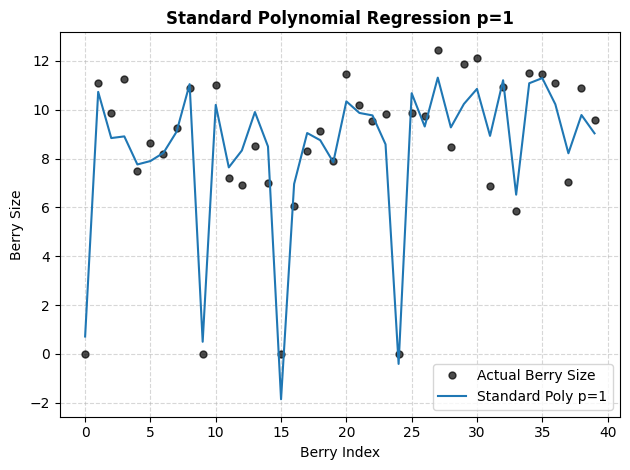

In [274]:
p = 1
beta_poly = poly_train(X_train_mat[p], y_train_f)    

results[f'Polynomial_{p}'] = test_coefficients(len(y_test), beta_poly, X_test_mat[p], y_test_f)
print("Polynomial MSE Results p=1:", results[f'Polynomial_{p}'])

plot_regression_results_matrix("Standard Polynomial", N_SUBSET, y_test_f, 1, X_test_mat, beta_poly)

The standard polynomial regression with order p=1 shows the best results for this dataset. I did not try other orders since there were numerical errors.

In [275]:
# save values of best model for equation derivation

feature_names = ["Intercept"] + list(X_train.columns)
weights_equation = beta_poly.flatten()

##### 3.1.3 BasicTree

Decision Tree MSE Results: 1.3334459686415343


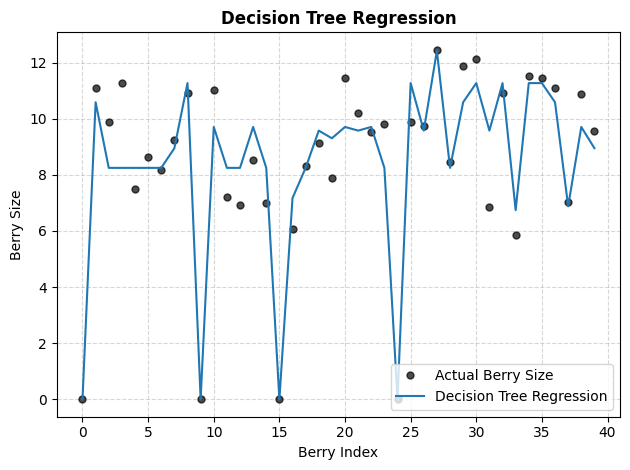

In [276]:
tree_root = TNode(0, X_train_f, y_train_f.flatten())
Construct_Subtree(tree_root, 5)

y_hat_tree = np.array([Predict(row, tree_root) for row in X_test_f])
results['Tree'] = np.mean((y_hat_tree - y_test_f.flatten())**2)

print("Decision Tree MSE Results:", results['Tree'])

plot_general_regression_results('Decision Tree', N_SUBSET, y_test_f, y_hat_tree)

The Decision Tree achieved an MSE of 1.3334, which is very good, but worse than the linear models. Its step logic where it groups berries into discrete categories based on True/False questions is useful for capturing relationships between features, but it lacks the precision of the continuous linear trend.

##### 3.1.4 Kernel

In [277]:
def k_func(x, u):
    return np.exp(-0.5 * np.linalg.norm(x - u)**2 / X_train_f.shape[1]) # used number of features for division

Kernel MSE Results: 14.599513343106498


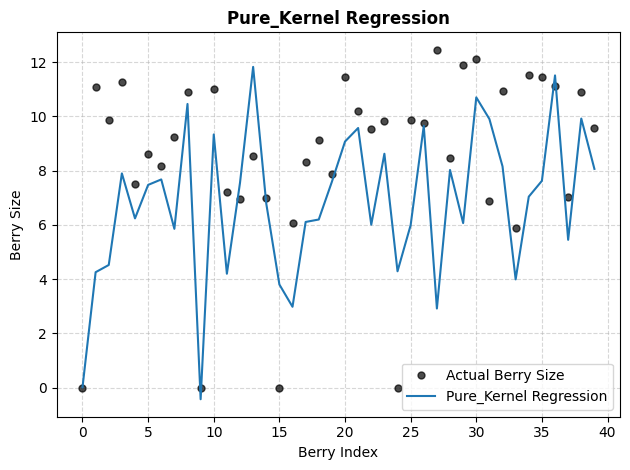

In [278]:
_, alpha_krnl = krnl.kernel_train(k_func, len(X_train_f), X_train_f, y_train_f.flatten())

y_hat_krnl = []
for x_t in X_test_f:
    kx = np.array([k_func(x_tr, x_t) for x_tr in X_train_f])
    y_hat_krnl.append(kx @ alpha_krnl)
    
results['Pure_Kernel'] = np.mean((np.array(y_hat_krnl) - y_test_f.flatten())**2)
print("Kernel MSE Results:", results['Pure_Kernel'])
plot_general_regression_results('Pure_Kernel', N_SUBSET, y_test_f, y_hat_krnl)

This model performed the worst, reaching an MSE of 14.5995. It seems to struggle significantly in high-dimensional spaces with a lot of features.

##### 3.1.5 Regularized Kernel

In [279]:
# added these functions to support N-D data

def kernel_predict_point(u_new, U_train, ad_coeffs, kernel_func, q_list):
    alpha = ad_coeffs[:len(U_train)]
    delta = ad_coeffs[len(U_train):]
    
    q_u = np.array([f(u_new) for f in q_list])
    prediction = q_u @ delta
    
    for i in range(len(U_train)):
        prediction += alpha[i] * kernel_func(u_new, U_train[i])
    return prediction

def k_reg(x1, x2):
    dot = np.dot(x1, x2)
    return dot + dot**2 + dot**3

def q2(x):
    return np.mean(x)

Regularized Kernel MSE Results: 8.255731056446018


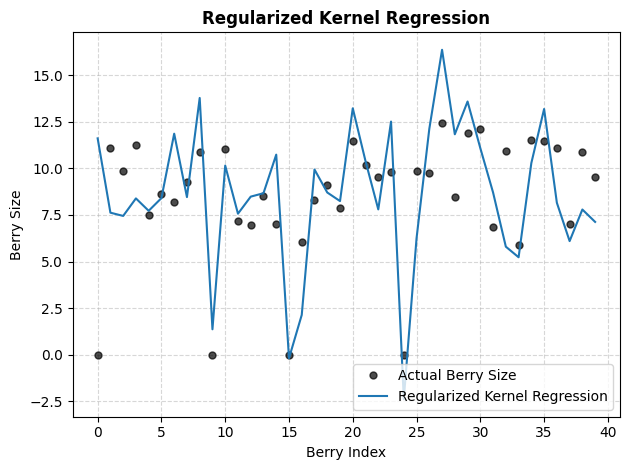

In [280]:
m = 2
q_funcs = [rkrnl.q1, q2]
ngamma_kernel = 0.5

ad_rk = rkrnl.kernel_train(k_reg, m, q_funcs, ngamma_kernel, len(X_train_f), X_train_f, y_train_f.flatten())

y_hat_regkernel = [kernel_predict_point(x, X_train_f, ad_rk, k_reg, q_funcs) for x in X_test_f]
results['Reg_Kernel'] = np.mean((np.array(y_hat_regkernel) - y_test_f.flatten())**2)
print("Regularized Kernel MSE Results:", results['Reg_Kernel'])
plot_general_regression_results('Regularized Kernel', N_SUBSET, y_test_f, y_hat_regkernel)

The regularized kernel model performed also badly, reaching an MSE of 8.2557. It also struggles in high-dimensional spaces with a lot of features.

##### 3.1.6 Polynomial Regression CV

In [281]:
ks = [2, 3, 5, 10, 20]  # using different Ks
n = len(y_train_f)
X = X_train_mat[1] # p=1
y = y_train_f
indices = np.arange(n)

cv_predictions = {}

for k_val in ks:
    preds = np.zeros(n)
    fold_size = n // k_val
    fold_mses = []
    
    for k in range(1, k_val + 1):
        # split
        test_ind = np.arange((k-1)*fold_size, k*fold_size)
        train_ind = np.setdiff1d(indices, test_ind)
        
        beta = poly_train(X[train_ind], y[train_ind])
        y_pred = X[test_ind] @ beta
        
        preds[test_ind] = y_pred.flatten()
        fold_mses.append(np.mean((y[test_ind].flatten() - y_pred.flatten())**2))
        
    cv_predictions[k_val] = preds
    results[f'Linear_CV_K{k_val}'] = np.mean(fold_mses)

print_list_MSE("Linear CV Regression", results, "CV")

Linear CV Regression MSE Results:
  - Linear_CV_K2: 1.2929
  - Linear_CV_K3: 1.3135
  - Linear_CV_K5: 1.2836
  - Linear_CV_K10: 1.3033
  - Linear_CV_K20: 1.2905


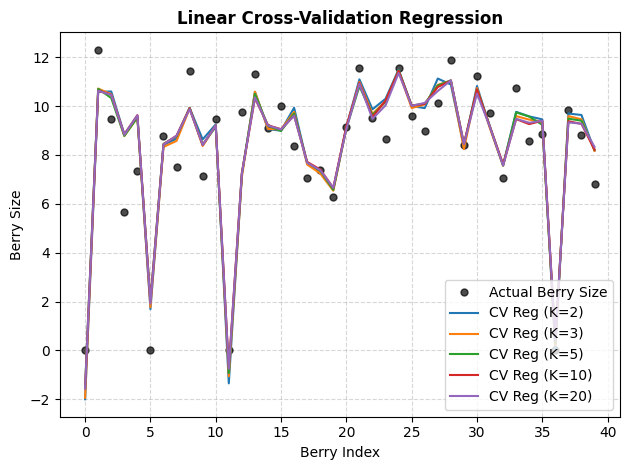

In [282]:
y_gt = y_train_f[:N_SUBSET].flatten()
plot_indices = np.arange(N_SUBSET)

plt.figure()
plt.plot(plot_indices, y_gt, 'k.', markersize=10, label='Actual Berry Size', alpha=0.7)

for k_val in ks:
    y_trend = cv_predictions[k_val][:N_SUBSET]
    plt.plot(plot_indices, y_trend, label=f'CV Reg (K={k_val})')

plt.title('Linear Cross-Validation Regression', fontweight='bold')
plt.xlabel('Berry Index')
plt.ylabel('Berry Size')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The CV Polynomial Regression performed very well for all Ks tried. By iterating through K values from 2 to 20, we observe that the Mean Squared Error remains stable. The best performance was achieved with K=5 and an MSE of 1.2835.

##### 3.1.7 Comparison

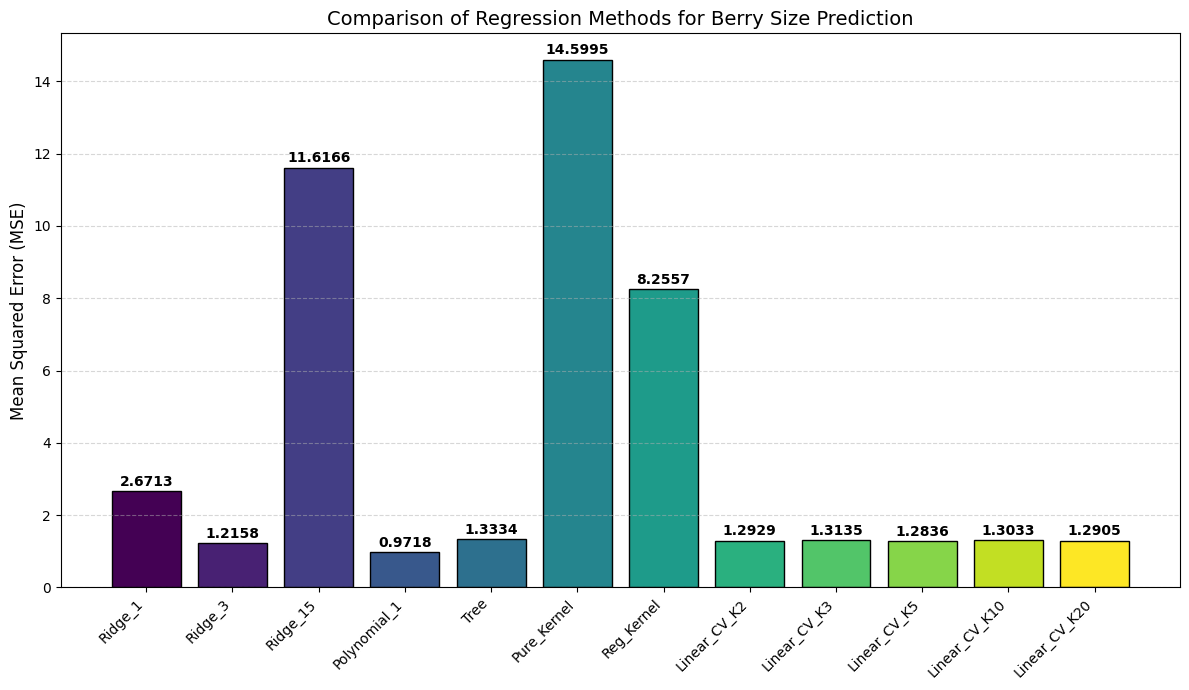

In [283]:
plt.figure(figsize=(12, 7))
names = list(results.keys())
values = list(results.values())

colors = plt.cm.viridis(np.linspace(0, 1, len(names)))

plt.bar(names, values, color=colors, edgecolor='black')
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Comparison of Regression Methods for Berry Size Prediction', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(values):
    plt.text(i, v + (max(values)*0.01), f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Based on the results, the Standard Polynomial Regression (p=1) achieved the lowest Mean Squared Error (0.9718), closely followed by the Ridge Regression at degree p=3 (1.2158), and the CV Regression at p=1 (1.2836). These results demonstrate that the relationship between berry characteristics and size is linear. While the Decision Tree provided a good fit (1.3334), it didn't perform as well as the regression models.

The more complicated models overfitted the berry data. The Polynomial degree p=15 and Kernel models had much higher errors (11.6165, 14.5995, and 8.2557 respectively). This confirms that adding excessive complexity causes the models to learn noise rather than learning generalizable patterns.

#### 3.2 Regression for edible berries only

To test if the performance improves when performing regression for edible berries only, I will use the same methods as above, keeping one test per method (the one that performed the best). I will omit all the plots this time to keep it shorter and visualize only in the end all the results together.

Setup

In [284]:
df_edible = df[df['edible'] == True]
df_edible = df_edible.drop(columns='edible')
df_edible

,age,leaf_size,berry_colour,berry_size,leaf_shape,petal_colour,petal_size,height,soil_quality,species
1,7.946372,27.694587,blue,8.569603,lanceolate,white,1.259286,165.247307,3.105685,berrius actius
2,3.572540,45.625918,blue,11.523105,lanceolate,white,2.319500,224.763124,5.540744,berrius actius
12,7.103687,14.837139,purple,5.412401,ovate,pink,3.574001,247.830811,4.276762,berrius boethiae
15,8.084762,50.370341,blue,11.347102,lanceolate,white,2.348196,535.728584,5.359247,berrius actius
23,5.488758,11.606615,purple,6.591031,ovate,pink,3.068812,199.956224,3.841800,berrius boethiae
...,...,...,...,...,...,...,...,...,...,...
482,6.039272,35.705908,blue,10.112243,lanceolate,white,1.796663,223.078951,4.595501,berrius actius
483,9.015481,46.166056,blue,10.612407,lanceolate,white,2.105595,524.420651,5.630916,berrius actius
488,9.055977,11.697371,purple,8.263144,ovate,pink,2.997505,346.001085,3.938024,berrius boethiae
489,7.094206,44.600618,blue,11.251908,lanceolate,white,1.755226,409.874540,4.987256,berrius actius


In [285]:
df_edible_encoded = pd.get_dummies(df_edible, columns=['berry_colour', 'leaf_shape', 'petal_colour', 'species'], drop_first=True)

X = df_edible_encoded.drop(columns=['berry_size'])
y = df_edible_encoded['berry_size']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_f = X_train.values.astype(float)
y_train_f = y_train.values.astype(float).reshape(-1, 1)
X_test_f = X_test.values.astype(float)
y_test_f = y_test.values.astype(float).reshape(-1, 1)

X_train_mat = {}
X_test_mat = {}

In [286]:
df_edible_encoded

,age,leaf_size,berry_size,petal_size,height,soil_quality,berry_colour_none,berry_colour_purple,leaf_shape_ovate,petal_colour_white,species_berrius boethiae
1,7.946372,27.694587,8.569603,1.259286,165.247307,3.105685,False,False,False,True,False
2,3.572540,45.625918,11.523105,2.319500,224.763124,5.540744,False,False,False,True,False
12,7.103687,14.837139,5.412401,3.574001,247.830811,4.276762,False,True,True,False,True
15,8.084762,50.370341,11.347102,2.348196,535.728584,5.359247,False,False,False,True,False
23,5.488758,11.606615,6.591031,3.068812,199.956224,3.841800,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
482,6.039272,35.705908,10.112243,1.796663,223.078951,4.595501,False,False,False,True,False
483,9.015481,46.166056,10.612407,2.105595,524.420651,5.630916,False,False,False,True,False
488,9.055977,11.697371,8.263144,2.997505,346.001085,3.938024,False,True,True,False,True
489,7.094206,44.600618,11.251908,1.755226,409.874540,4.987256,False,False,False,True,False


##### 3.2.1 Regularized Polynomial Regression - Edible

In [287]:
gamma = 0.1
ps = [1, 3, 15] # trying 3 different polynomial orders
betas_ridge = {}

for p in ps:
    X_train_mat[p] = model_matrix(p, X_train_f)
    X_test_mat[p] = model_matrix(p, X_test_f)
    
    betas_ridge[p] = ridge_train(X_train_mat[p], 
                             y_train_f, 
                             len(X_train)*gamma, 
                             X_train_mat[p].shape[1] - 1)
    
    results[f'Edible_Ridge_{p}'] = test_coefficients(len(y_test), betas_ridge[p], X_test_mat[p], y_test_f)

print_list_MSE("Ridge Regression ", results, "Ridge")

Ridge Regression  MSE Results:
  - Ridge_1: 2.6713
  - Ridge_3: 1.2158
  - Ridge_15: 11.6166
  - Edible_Ridge_1: 2.9293
  - Edible_Ridge_3: 1.4889
  - Edible_Ridge_15: 23998052.8008


For the Regularized Ridge Regression, I tried the same 3 experiments. The orders p=1 and p=3 both performed very well, with their MSE being slightly worse than it was with the complete dataset. Order p=15 overfits much more with the fewer data, showing a huge MSE.

##### 3.2.2 Standard Polynomial Regression - Edible

To run the Standard Polynomial Regression, I had to remove some columns from the model matrix, because filtering the dataset to only edible only berries created 0 variance features and identical columns, which result in a singular matrix that the standard linear solver cannot invert. So I removed all 0 variance and identical columns and then was able to run it.

In [288]:
import numpy as np

p = 1
X_tr_mat = X_train_mat[p]
X_tst_mat = X_test_mat[p]

# removed 0 variance columns
valid_var = np.var(X_tr_mat, axis=0) > 0
X_tr_mat = X_tr_mat[:, valid_var]
X_tst_mat = X_tst_mat[:, valid_var]

# remove redundant columns (identical)
_, unique_indices = np.unique(X_tr_mat, axis=1, return_index=True)
unique_indices = np.sort(unique_indices)

X_tr_mat = X_tr_mat[:, unique_indices]
X_tst_mat = X_tst_mat[:, unique_indices]

beta_poly = poly_train(X_tr_mat, y_train_f)    
results[f'Edible_Polynomial_{p}'] = test_coefficients(len(y_test_f), beta_poly, X_tst_mat, y_test_f)

print_list_MSE("Polynomial Regression ", results, "Polynomial")

Polynomial Regression  MSE Results:
  - Polynomial_1: 0.9718
  - Edible_Polynomial_1: 1.1559


The standard polynomial regression with order p=1 shows the best results also for the edible only dataset. Still, the complete dataset outperforms it.

##### 3.2.3 BasicTree - Edible

In [289]:
tree_root = TNode(0, X_train_f, y_train_f.flatten())
Construct_Subtree(tree_root, 5)

y_hat_tree = np.array([Predict(row, tree_root) for row in X_test_f])
results['Edible_Tree'] = np.mean((y_hat_tree - y_test_f.flatten())**2)

print_list_MSE("Decision Tree Regression - Edible only", results, "Tree")

Decision Tree Regression - Edible only MSE Results:
  - Tree: 1.3334
  - Edible_Tree: 3.7368


The Decision Tree for edible berries only achieved an MSE of 3.73681.3334, getting worse with the edible only dataset.

##### 3.2.4 Kernel - Edible

In [290]:
_, alpha_krnl = krnl.kernel_train(k_func, len(X_train_f), X_train_f, y_train_f.flatten())

y_hat_krnl = []
for x_t in X_test_f:
    kx = np.array([k_func(x_tr, x_t) for x_tr in X_train_f])
    y_hat_krnl.append(kx @ alpha_krnl)
    
results['Edible_Pure_Kernel'] = np.mean((np.array(y_hat_krnl) - y_test_f.flatten())**2)
print_list_MSE("Pure_Kernel - Edible only", results, "Pure_Kernel")

Pure_Kernel - Edible only MSE Results:
  - Pure_Kernel: 14.5995
  - Edible_Pure_Kernel: 55.2111


The pure kernel model performed much worse, reaching an MSE of 55.2111. It seems to struggle even more with fewer data.

##### 3.2.5 Regularized Kernel - Edible

In [291]:
m = 2
q_funcs = [rkrnl.q1, q2]
ngamma_kernel = 0.5

ad_rk = rkrnl.kernel_train(k_reg, m, q_funcs, ngamma_kernel, len(X_train_f), X_train_f, y_train_f.flatten())

y_hat_regkernel = [kernel_predict_point(x, X_train_f, ad_rk, k_reg, q_funcs) for x in X_test_f]
results['Edible_Reg_Kernel'] = np.mean((np.array(y_hat_regkernel) - y_test_f.flatten())**2)
print_list_MSE("Regularized Kernel - Edible only", results, "Reg_Kernel")

Regularized Kernel - Edible only MSE Results:
  - Reg_Kernel: 8.2557
  - Edible_Reg_Kernel: 1.9562


The regularized kernel model performed well this time, reaching an MSE of 1.9562. This is the only algorithm in my experiments that performs better with the edible only dataset.

##### 3.2.6 Polynomial Regression CV - Edible

In [292]:
ks = [2, 3, 5, 10, 20]  # using different Ks
n = len(y_train_f)
X = X_tr_mat
y = y_train_f
indices = np.arange(n)

cv_predictions = {}

for k_val in ks:
    preds = np.zeros(n)
    fold_size = n // k_val
    fold_mses = []
    
    for k in range(1, k_val + 1):
        # split
        test_ind = np.arange((k-1)*fold_size, k*fold_size)
        train_ind = np.setdiff1d(indices, test_ind)
        
        beta = poly_train(X[train_ind], y[train_ind])
        y_pred = X[test_ind] @ beta
        
        preds[test_ind] = y_pred.flatten()
        fold_mses.append(np.mean((y[test_ind].flatten() - y_pred.flatten())**2))
        
    cv_predictions[k_val] = preds
    results[f'Edible_Linear_CV_K{k_val}'] = np.mean(fold_mses)

print_list_MSE("Linear CV Regression", results, "CV")

Linear CV Regression MSE Results:
  - Linear_CV_K2: 1.2929
  - Linear_CV_K3: 1.3135
  - Linear_CV_K5: 1.2836
  - Linear_CV_K10: 1.3033
  - Linear_CV_K20: 1.2905
  - Edible_Linear_CV_K2: 1.5539
  - Edible_Linear_CV_K3: 1.6409
  - Edible_Linear_CV_K5: 1.4294
  - Edible_Linear_CV_K10: 1.4433
  - Edible_Linear_CV_K20: 1.3029


The CV Polynomial Regression performed very well for all Ks tried, maintaining a stable MSE. The best performance this time was achieved with K=20 and an MSE of 1.3029. For all Ks, using the edible only dataset makes the performance a bit worse.

##### 3.2.7 Comparison Complete vs Edible

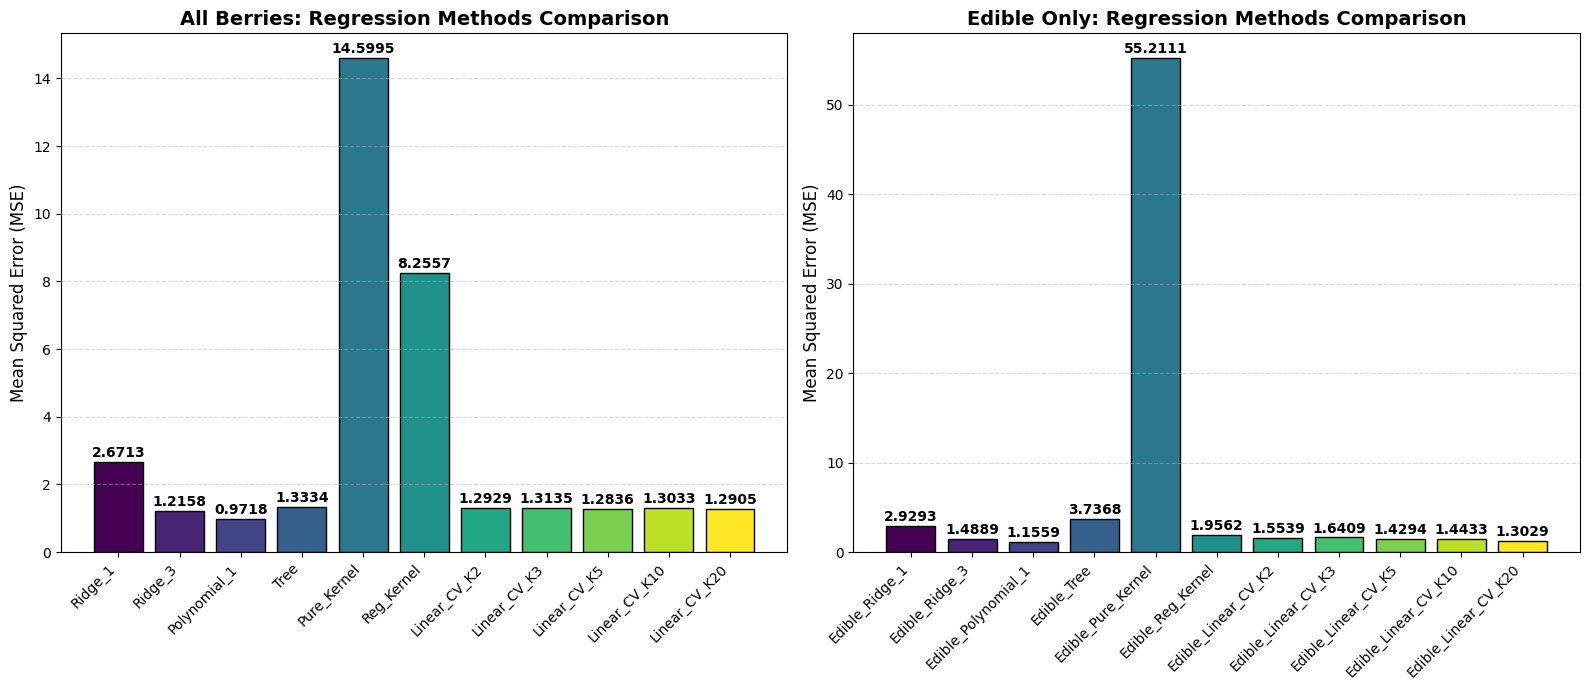

In [293]:
edible_results = {}
all_results = {}

for key, value in results.items():
    if 'Ridge_15' in key: # skipping this because the error is huge and it is breaking the plot
        continue
        
    if 'Edible_' in key:
        edible_results[key] = value
    else:
        all_results[key] = value

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

names_all = list(all_results.keys())
values_all = list(all_results.values())
colors_all = plt.cm.viridis(np.linspace(0, 1, len(names_all)))

ax1.bar(names_all, values_all, color=colors_all, edgecolor='black')
ax1.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax1.set_title('All Berries: Regression Methods Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(names_all)))
ax1.set_xticklabels(names_all, rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

if values_all:
    for i, v in enumerate(values_all):
        ax1.text(i, v + (max(values_all)*0.01), f"{v:.4f}", ha='center', fontweight='bold')

names_edible = list(edible_results.keys())
values_edible = list(edible_results.values())
colors_edible = plt.cm.viridis(np.linspace(0, 1, len(names_edible)))

ax2.bar(names_edible, values_edible, color=colors_edible, edgecolor='black')
ax2.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax2.set_title('Edible Only: Regression Methods Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(names_edible)))
ax2.set_xticklabels(names_edible, rotation=45, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

if values_edible:
    for i, v in enumerate(values_edible):
        ax2.text(i, v + (max(values_edible)*0.01), f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Based on the results, the prediction accuracy decreases when restricting the dataset to only edible berries. The best model, the Standard Polynomial Regression (p=1), showed an MSE increase from 0.9718 to 1.1559. This trend of increased error was consistent across the Ridge Regression, Decision Tree, and Cross-Validation results. This degradation occurs because filtering out the inedible berries significantly reduces the total number of training samples and the models require sufficient data to generale well. 

The only model that showed improvement is the Regularized Kernel, dropping from an MSE of 8.2557 to 1.9562.

#### 3.3 Explicit expression for berry size calculation

To derive an expression for the berry calculation, I used the Standard Polynomial Regression weights since it was the best performing model, with the model matrix of the original full dataset. So I built the linear equation, adding the intercept term in the front without a variable, and then the sum of all the features multiplied by their corresponding weights.

In [294]:
equation = f"Berry Size = {weights_equation[0]:.4f}"
for name, coef in zip(feature_names[1:], weights_equation[1:]):
    sign = "+" if coef >= 0 else "-"
    equation += f" {sign} {abs(coef):.4f} * {name}"

print(equation)

Berry Size = -721.9408 - 0.0509 * age - 0.0075 * leaf_size + 0.2799 * petal_size + 0.0002 * height + 0.0229 * edible + 1.1155 * soil_quality - 155.4882 * berry_colour_blue - 155.9044 * berry_colour_green - 155.7711 * berry_colour_grey - 165.5376 * berry_colour_none - 155.9273 * berry_colour_purple + 610.7695 * leaf_shape_lanceolate + 1340.5091 * leaf_shape_ovate - 928.9017 * petal_colour_pink + 375.4940 * petal_colour_white - 104.1256 * species_berrius actius + 468.1802 * species_berrius boethiae - 833.6272 * species_berrius codiae + 469.9101 * species_berrius delphinorum - 104.8868 * species_berrius elephas


#### 3.4 Features subset

I will try the same algorithms as above, using the complete dataset, and omitting the soil type and age that are the most difficult to calculate.

Setup

In [295]:
df = df.drop(columns=['soil_quality', 'age'])
df

,leaf_size,berry_colour,berry_size,leaf_shape,petal_colour,petal_size,height,edible,species
0,24.510278,grey,7.959125,lanceolate,white,3.118933,239.007710,False,berrius elephas
1,27.694587,blue,8.569603,lanceolate,white,1.259286,165.247307,True,berrius actius
2,45.625918,blue,11.523105,lanceolate,white,2.319500,224.763124,True,berrius actius
3,11.864775,green,6.010535,ovate,pink,3.159112,69.530241,False,berrius boethiae
4,18.736034,green,6.506491,lanceolate,white,2.477067,45.883920,False,berrius elephas
...,...,...,...,...,...,...,...,...,...
495,14.665505,purple,6.076126,ovate,pink,3.130601,205.911846,True,berrius boethiae
496,25.466863,green,7.526041,lanceolate,white,1.101837,33.783400,False,berrius actius
497,26.944936,purple,9.737714,ovate,white,2.584270,230.943919,False,berrius codiae
498,26.458160,green,9.546730,lanceolate,white,1.402115,37.092050,False,berrius actius


In [296]:
df_encoded = pd.get_dummies(df, columns=['berry_colour', 'leaf_shape', 'petal_colour', 'species'])

X = df_encoded.drop(columns=['berry_size'])
y = df_encoded['berry_size']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_f = X_train.values.astype(float)
y_train_f = y_train.values.astype(float).reshape(-1, 1)
X_test_f = X_test.values.astype(float)
y_test_f = y_test.values.astype(float).reshape(-1, 1)

X_train_mat = {}
X_test_mat = {}

In [297]:
df_edible_encoded

,age,leaf_size,berry_size,petal_size,height,soil_quality,berry_colour_none,berry_colour_purple,leaf_shape_ovate,petal_colour_white,species_berrius boethiae
1,7.946372,27.694587,8.569603,1.259286,165.247307,3.105685,False,False,False,True,False
2,3.572540,45.625918,11.523105,2.319500,224.763124,5.540744,False,False,False,True,False
12,7.103687,14.837139,5.412401,3.574001,247.830811,4.276762,False,True,True,False,True
15,8.084762,50.370341,11.347102,2.348196,535.728584,5.359247,False,False,False,True,False
23,5.488758,11.606615,6.591031,3.068812,199.956224,3.841800,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
482,6.039272,35.705908,10.112243,1.796663,223.078951,4.595501,False,False,False,True,False
483,9.015481,46.166056,10.612407,2.105595,524.420651,5.630916,False,False,False,True,False
488,9.055977,11.697371,8.263144,2.997505,346.001085,3.938024,False,True,True,False,True
489,7.094206,44.600618,11.251908,1.755226,409.874540,4.987256,False,False,False,True,False


##### 3.4.1 Regularized Polynomial Regression - Subset

In [298]:
gamma = 0.1
ps = [1, 3, 15] # trying 3 different polynomial orders
betas_ridge = {}

for p in ps:
    X_train_mat[p] = model_matrix(p, X_train_f)
    X_test_mat[p] = model_matrix(p, X_test_f)
    
    betas_ridge[p] = ridge_train(X_train_mat[p], 
                             y_train_f, 
                             len(X_train)*gamma, 
                             X_train_mat[p].shape[1] - 1)
    
    results[f'Subset_Ridge_{p}'] = test_coefficients(len(y_test), betas_ridge[p], X_test_mat[p], y_test_f)

print_list_MSE("Ridge Regression ", results, "Ridge")

Ridge Regression  MSE Results:
  - Ridge_1: 2.6713
  - Ridge_3: 1.2158
  - Ridge_15: 11.6166
  - Edible_Ridge_1: 2.9293
  - Edible_Ridge_3: 1.4889
  - Edible_Ridge_15: 23998052.8008
  - Subset_Ridge_1: 2.8408
  - Subset_Ridge_3: 1.3483
  - Subset_Ridge_15: 2.2373


For the Regularized Ridge Regression, I tried the same 3 experiments. The orders p=1 and p=3 both performed slightly worse with the subset dataset. By dropping the 2 features soil and age, order p=15 stops overfitting, achieving an MSE of 2.2373.

##### 3.4.2 Standard Polynomial Regression - Subset

To run the Standard Polynomial Regression, I removed all 0 variance and identical columns as I did for the edible only dataset.

In [299]:
import numpy as np

p = 1
X_tr_mat = X_train_mat[p]
X_tst_mat = X_test_mat[p]

# removed 0 variance columns
valid_var = np.var(X_tr_mat, axis=0) > 0
X_tr_mat = X_tr_mat[:, valid_var]
X_tst_mat = X_tst_mat[:, valid_var]

# remove redundant columns (identical)
_, unique_indices = np.unique(X_tr_mat, axis=1, return_index=True)
unique_indices = np.sort(unique_indices)

X_tr_mat = X_tr_mat[:, unique_indices]
X_tst_mat = X_tst_mat[:, unique_indices]

beta_poly = poly_train(X_tr_mat, y_train_f)    
results[f'Subset_Polynomial_{p}'] = test_coefficients(len(y_test_f), beta_poly, X_tst_mat, y_test_f)

print_list_MSE("Polynomial Regression ", results, "Polynomial")

Polynomial Regression  MSE Results:
  - Polynomial_1: 0.9718
  - Edible_Polynomial_1: 1.1559
  - Subset_Polynomial_1: 1.1004


The standard polynomial regression with order p=1 shows the best results also for the subset dataset. Still, the complete dataset outperforms it.

##### 3.4.3 BasicTree - Subset

In [300]:
tree_root = TNode(0, X_train_f, y_train_f.flatten())
Construct_Subtree(tree_root, 5)

y_hat_tree = np.array([Predict(row, tree_root) for row in X_test_f])
results['Subset_Tree'] = np.mean((y_hat_tree - y_test_f.flatten())**2)

print_list_MSE("Decision Tree Regression - Edible only", results, "Tree")

Decision Tree Regression - Edible only MSE Results:
  - Tree: 1.3334
  - Edible_Tree: 3.7368
  - Subset_Tree: 1.3449


The Decision Tree for edible berries achieved an MSE of 1.3449, almost equal with the MSE of the complete dataset (1.3334).

##### 3.4.4 Kernel - Subset

In [301]:
_, alpha_krnl = krnl.kernel_train(k_func, len(X_train_f), X_train_f, y_train_f.flatten())

y_hat_krnl = []
for x_t in X_test_f:
    kx = np.array([k_func(x_tr, x_t) for x_tr in X_train_f])
    y_hat_krnl.append(kx @ alpha_krnl)
    
results['Subset_Pure_Kernel'] = np.mean((np.array(y_hat_krnl) - y_test_f.flatten())**2)
print_list_MSE("Pure_Kernel - Edible only", results, "Pure_Kernel")

Pure_Kernel - Edible only MSE Results:
  - Pure_Kernel: 14.5995
  - Edible_Pure_Kernel: 55.2111
  - Subset_Pure_Kernel: 15.2599


The pure kernel model continues performing badly, achieving a slightly worse MSE of 15.2599.

##### 3.4.5 Regularized Kernel - Subset

In [302]:
m = 2
q_funcs = [rkrnl.q1, q2]
ngamma_kernel = 0.5

ad_rk = rkrnl.kernel_train(k_reg, m, q_funcs, ngamma_kernel, len(X_train_f), X_train_f, y_train_f.flatten())

y_hat_regkernel = [kernel_predict_point(x, X_train_f, ad_rk, k_reg, q_funcs) for x in X_test_f]
results['Subset_Reg_Kernel'] = np.mean((np.array(y_hat_regkernel) - y_test_f.flatten())**2)
print_list_MSE("Regularized Kernel - Edible only", results, "Reg_Kernel")

Regularized Kernel - Edible only MSE Results:
  - Reg_Kernel: 8.2557
  - Edible_Reg_Kernel: 1.9562
  - Subset_Reg_Kernel: 1.6714


The regularized kernel model performed well with the subset dataset, reaching an MSE of 1.6714. This is the only algorithm in my experiments that performs better with the subset.

##### 3.4.6 Polynomial Regression CV - Subset

In [303]:
ks = [2, 3, 5, 10]  # using different Ks
n = len(y_train_f)
X = X_tr_mat
y = y_train_f
indices = np.arange(n)

cv_predictions = {}

for k_val in ks:
    preds = np.zeros(n)
    fold_size = n // k_val
    fold_mses = []
    
    for k in range(1, k_val + 1):
        # split
        test_ind = np.arange((k-1)*fold_size, k*fold_size)
        train_ind = np.setdiff1d(indices, test_ind)
        
        beta = poly_train(X[train_ind], y[train_ind])
        y_pred = X[test_ind] @ beta
        
        preds[test_ind] = y_pred.flatten()
        fold_mses.append(np.mean((y[test_ind].flatten() - y_pred.flatten())**2))
        
    cv_predictions[k_val] = preds
    results[f'Subset_Linear_CV_K{k_val}'] = np.mean(fold_mses)

print_list_MSE("Linear CV Regression", results, "CV")

Linear CV Regression MSE Results:
  - Linear_CV_K2: 1.2929
  - Linear_CV_K3: 1.3135
  - Linear_CV_K5: 1.2836
  - Linear_CV_K10: 1.3033
  - Linear_CV_K20: 1.2905
  - Edible_Linear_CV_K2: 1.5539
  - Edible_Linear_CV_K3: 1.6409
  - Edible_Linear_CV_K5: 1.4294
  - Edible_Linear_CV_K10: 1.4433
  - Edible_Linear_CV_K20: 1.3029
  - Subset_Linear_CV_K2: 1.3870
  - Subset_Linear_CV_K3: 1.3651
  - Subset_Linear_CV_K5: 1.3767
  - Subset_Linear_CV_K10: 1.3828


The CV Polynomial Regression performed very well for all Ks tried, maintaining a stable MSE. The best performance this time was achieved with K=3 and an MSE of 1.3651. I omitted the K=20 fold because it was having again issues with the variance of the splits. For all Ks, using the subset dataset makes the performance a bit worse.

##### 3.4.7 Comparison Complete vs Subset

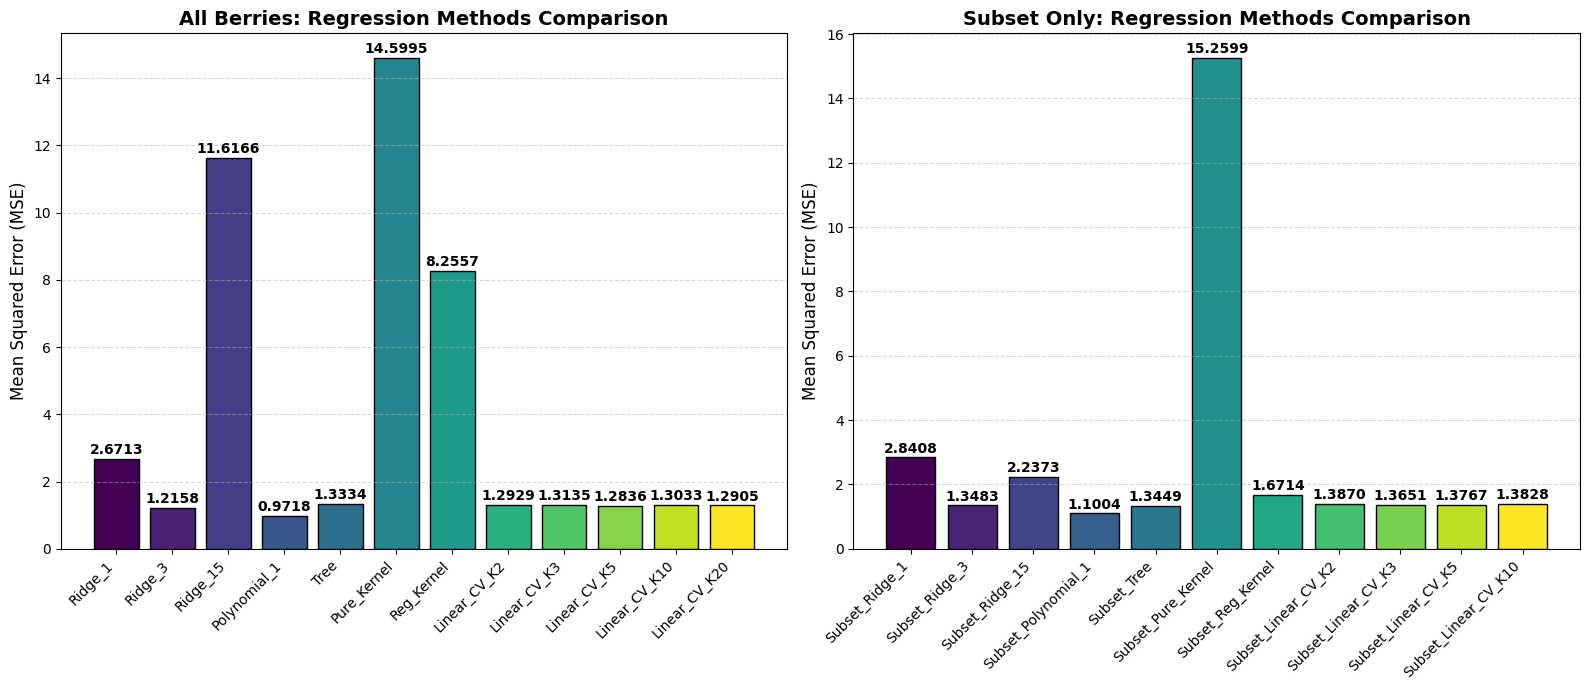

In [307]:
subset_results = {}
all_results = {}

for key, value in results.items():
    if 'K_20' in key: # skipping omitted fold
        continue
        
    if 'Subset_' in key:
        subset_results[key] = value
    elif 'Edible_' in key:
        pass
    else:
        all_results[key] = value

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

names_all = list(all_results.keys())
values_all = list(all_results.values())
colors_all = plt.cm.viridis(np.linspace(0, 1, len(names_all)))

ax1.bar(names_all, values_all, color=colors_all, edgecolor='black')
ax1.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax1.set_title('All Berries: Regression Methods Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(names_all)))
ax1.set_xticklabels(names_all, rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

if values_all:
    for i, v in enumerate(values_all):
        ax1.text(i, v + (max(values_all)*0.01), f"{v:.4f}", ha='center', fontweight='bold')

names_sub = list(subset_results.keys())
values_sub = list(subset_results.values())
colors_sub = plt.cm.viridis(np.linspace(0, 1, len(names_sub)))

ax2.bar(names_sub, values_sub, color=colors_sub, edgecolor='black')
ax2.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax2.set_title('Subset Only: Regression Methods Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(names_sub)))
ax2.set_xticklabels(names_sub, rotation=45, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

if values_sub:
    for i, v in enumerate(values_sub):
        ax2.text(i, v + (max(values_sub)*0.01), f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

While dropping the soil quality and age features deteriorates a bit the predictions, the difference is negligible. We can still easily predict the berry size accurately without these 2 features. The baseline error increases by ~0.13, so the remaining features carry more information about the size. Therefore, we can still have accurate predictions without being experts that can calculate these features. Again, Regularized Kernel is the only model that performs better with the subset.

Through this analysis we show that we can predict the berry sizes very effectively using the info we have.

Across all datasets, the Standard Polynomial Regression at degree p=1 consistently achieved the lowest Mean Squared Error, closely followed by Ridge Regression (p=3). The p=15 polynomial resulted in severe overfitting. Similarly, distance-based Kernel methods failed to generalize effectively. The stability of the simple linear model was shown through K-fold Cross-Validation, confirming that the rules for calculating the berry size are fundamentally linear and can be reliably captured without complex polynomial transformations.

When the dataset was restricted strictly to edible berries, prediction error increased across the baseline models (the optimal p=1 model error increased from 0.9718 to 1.1559). While this subset is more practical, the reduction in total training samples affects the algorithms performance.

The models remains highly reliable even when some features are removed variables are removed. Dropping the soil quality and the age resulted in a negligible penalty, shifting the baseline linear MSE by only ~0.13, showing that the most important features are the easily observable traits such as physical dimensions, and colour.